# Imports

In [19]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import SparseLinear
from utils import get_dataloaders, train_model, evaluate
from visualization_utils import plot_accuracy_over_epochs, plot_training_time_comparison, create_training_time_table, create_accuracy_summary_table


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"


# List of Keep Ratios and Training Variables

In [4]:
list_of_sparse_keep_ratios = [1, .9, .8, .7, .6, .5, .4]

# store results by dataset name so the plotting helpers can reuse them
# structure:
# dataset_acc_results[dataset_name] = {
#     'dense': dense_acc,
#     'sparse': {keep_ratio: sparse_acc, ...}
# }
# dataset_time_results[dataset_name] = {
#     'dense': dense_time,
#     'sparse': {keep_ratio: sparse_time, ...}
# }
dataset_acc_results = {}
dataset_time_results = {}

epochs = 5
learning_rate = 0.01


# Dataset selection and helper
Use `dataset_name` to choose which dataset to load. Hyphenated names like `CIFAR-10` are normalized below.

In [5]:
# Helper to normalize names and load datasets
def normalize_dataset_name(name):
    n = name.lower().strip()
    # common aliases
    if 'cifar-10' in n or 'cifar10' in n or 'cifar_10' in n:
        return 'CIFAR10'
    if 'cifar-100' in n or 'cifar100' in n or 'cifar_100' in n:
        return 'CIFAR100'
    if 'fashion' in n and 'mnist' in n:
        return 'Fashion-MNIST'
    if 'kmnist' in n or 'k-mnist' in n:
        return 'KMNIST'
    if 'svhn' in n:
        return 'SVHN'
    if 'tiny' in n and 'imagenet' in n:
        return 'Tiny-ImageNet'
    if 'uci' in n or 'adult' in n:
        return 'UCI-Adult'
    if 'covertype' in n:
        return 'Covertype'
    # fallback: try raw name
    return name


In [6]:
# Example: change full_dataset_name to test others
full_dataset_name = 'MNIST'
full_dataset_name = normalize_dataset_name(full_dataset_name)
print('Loading dataset:', full_dataset_name)
try:
    train_loader, test_loader = get_dataloaders(full_dataset_name, batch_size_train=128, batch_size_test=256, data_dir='./data')
    xb,yb = next(iter(train_loader))
    print('train batch shape:', xb.shape, yb.shape)
except Exception as e:
    print('Loader error:', type(e).__name__, e)

Loading dataset: MNIST
train batch shape: torch.Size([128, 1, 28, 28]) torch.Size([128])


# Models Factory

In [7]:
import importlib
import models as models_module
importlib.reload(models_module)

from models import (
    CIFAR10DenseModel, CIFAR10SparseModel,
    CIFAR100DenseModel, CIFAR100SparseModel,
    MNISTDenseModel, MNISTSparseModel,
    FashionMNISTDenseModel, FashionMNISTSparseModel,
    KMNISTDenseModel, KMNISTSparseModel,
    SVHNDenseModel, SVHNSparseModel,
    TinyImageNetDenseModel, TinyImageNetSparseModel,
    UCIAdultDenseModel, UCIAdultSparseModel,
    CovertypeDenseModel, CovertypeSparseModel,
)

models_factory = {
    'MNIST': {
        'dense_cls': MNISTDenseModel,
        'sparse_cls': MNISTSparseModel,
        'dense_kwargs': {},
        'sparse_kwargs': {},
    },
    'Fashion-MNIST': {
        'dense_cls': FashionMNISTDenseModel,
        'sparse_cls': FashionMNISTSparseModel,
        'dense_kwargs': {},
        'sparse_kwargs': {},
    },
    'KMNIST': {
        'dense_cls': KMNISTDenseModel,
        'sparse_cls': KMNISTSparseModel,
        'dense_kwargs': {},
        'sparse_kwargs': {},
    },
    'CIFAR10': {
        'dense_cls': CIFAR10DenseModel,
        'sparse_cls': CIFAR10SparseModel,
        'dense_kwargs': {},
        'sparse_kwargs': {},
    },
    'CIFAR100': {
        'dense_cls': CIFAR100DenseModel,
        'sparse_cls': CIFAR100SparseModel,
        'dense_kwargs': {},
        'sparse_kwargs': {},
    },
    'SVHN': {
        'dense_cls': SVHNDenseModel,
        'sparse_cls': SVHNSparseModel,
        'dense_kwargs': {},
        'sparse_kwargs': {},
    },
    'Tiny-ImageNet': {
        'dense_cls': TinyImageNetDenseModel,
        'sparse_cls': TinyImageNetSparseModel,
        'dense_kwargs': {},
        'sparse_kwargs': {},
    },
    'UCI-Adult': {
        'dense_cls': UCIAdultDenseModel,
        'sparse_cls': UCIAdultSparseModel,
        'dense_kwargs': {'input_features': 105, 'num_classes': 2},
        'sparse_kwargs': {'input_features': 105, 'num_classes': 2},
    },
    'Covertype': {
        'dense_cls': CovertypeDenseModel,
        'sparse_cls': CovertypeSparseModel,
        'dense_kwargs': {'input_features': 98, 'num_classes': 7},
        'sparse_kwargs': {'input_features': 98, 'num_classes': 7},
    },
}


# Dense vs Sparse Training
Train models for multiple epochs on to compare accuracy and training time.

In [8]:
# Full training for any supported dataset name
# Examples: 'MNIST', 'CIFAR10', 'CIFAR100', 'Fashion-MNIST', 'SVHN', 'KMNIST', 'Tiny-ImageNet', 'UCI-Adult', 'Covertype'

try:
    train_loader_full, test_loader_full = get_dataloaders(full_dataset_name, batch_size_train=128, batch_size_test=256, data_dir='./data')
except Exception as e:
    print(f'{full_dataset_name} loader error:', e)
    train_loader_full = None

if train_loader_full is not None:
    dataset_config = models_factory.get(full_dataset_name)
    if dataset_config is None:
        print(f'No model factory registered for {full_dataset_name}')
    else:
        print('\n' + '='*60)
        print(f'Training DENSE {full_dataset_name} model ({epochs} epochs)...')
        print('='*60)

        dense_kwargs = dict(dataset_config['dense_kwargs'])
        if full_dataset_name in ('UCI-Adult', 'Covertype'):
            sample_features = next(iter(train_loader_full))[0].shape[1]
            dense_kwargs['input_features'] = sample_features
        dense_model_full = dataset_config['dense_cls'](**dense_kwargs)
        dense_full_acc, dense_full_time = train_model(dense_model_full, train_loader_full, test_loader_full, epochs=epochs, lr=learning_rate)
        print(f'\n{full_dataset_name} Dense Final Accuracy: {dense_full_acc[-1]:.4f}')
        print(f'{full_dataset_name} Dense Training Time: {dense_full_time:.2f}s')

        sparse_keep_ratios_for_run = list_of_sparse_keep_ratios
        sparse_full_accuracies = []
        sparse_full_times = []

        for keep_ratio in sparse_keep_ratios_for_run:
            print('\n' + '='*60)
            print(f'Training SPARSE {full_dataset_name} model ({keep_ratio*100:.0f}% Keep Ratio, {epochs} epochs)...')
            print('='*60)
            sparse_kwargs = dict(dataset_config['sparse_kwargs'])
            if full_dataset_name in ('UCI-Adult', 'Covertype'):
                sparse_kwargs['input_features'] = dense_kwargs['input_features']
            sparse_kwargs['keep_ratio'] = keep_ratio
            sparse_model_full = dataset_config['sparse_cls'](**sparse_kwargs)
            sparse_acc, sparse_time = train_model(sparse_model_full, train_loader_full, test_loader_full, epochs=epochs, lr=learning_rate)
            sparse_full_accuracies.append(sparse_acc)
            sparse_full_times.append(sparse_time)
            print(f'{full_dataset_name} Sparse ({keep_ratio*100:.0f}%) Final Accuracy: {sparse_acc[-1]:.4f}')
            print(f'{full_dataset_name} Sparse ({keep_ratio*100:.0f}%) Training Time: {sparse_time:.2f}s')

        dataset_acc_results[full_dataset_name] = {
            'dense': dense_full_acc,
            'sparse': {keep_ratio: sparse_acc for keep_ratio, sparse_acc in zip(sparse_keep_ratios_for_run, sparse_full_accuracies)}
        }
        dataset_time_results[full_dataset_name] = {
            'dense': dense_full_time,
            'sparse': {keep_ratio: sparse_time for keep_ratio, sparse_time in zip(sparse_keep_ratios_for_run, sparse_full_times)}
        }



Training DENSE MNIST model (5 epochs)...
Epoch 1 | Loss: 0.7382 | Accuracy: 0.9145
Epoch 2 | Loss: 0.2726 | Accuracy: 0.9357
Epoch 3 | Loss: 0.2032 | Accuracy: 0.9473
Epoch 4 | Loss: 0.1592 | Accuracy: 0.9568
Epoch 5 | Loss: 0.1296 | Accuracy: 0.9611

MNIST Dense Final Accuracy: 0.9611
MNIST Dense Training Time: 15.91s

Training SPARSE MNIST model (100% Keep Ratio, 5 epochs)...
Epoch 1 | Loss: 0.4715 | Accuracy: 0.9277
Epoch 2 | Loss: 0.2097 | Accuracy: 0.9493
Epoch 3 | Loss: 0.1547 | Accuracy: 0.9540
Epoch 4 | Loss: 0.1230 | Accuracy: 0.9658
Epoch 5 | Loss: 0.1002 | Accuracy: 0.9694
MNIST Sparse (100%) Final Accuracy: 0.9694
MNIST Sparse (100%) Training Time: 17.03s

Training SPARSE MNIST model (90% Keep Ratio, 5 epochs)...
Epoch 1 | Loss: 0.5066 | Accuracy: 0.9246
Epoch 2 | Loss: 0.2288 | Accuracy: 0.9450
Epoch 3 | Loss: 0.1732 | Accuracy: 0.9521
Epoch 4 | Loss: 0.1391 | Accuracy: 0.9598
Epoch 5 | Loss: 0.1148 | Accuracy: 0.9665
MNIST Sparse (90%) Final Accuracy: 0.9665
MNIST Sparse

# Visualization

In [9]:
# print trained models in dictionaries
print('\n' + '='*60)
print('Trained Models Summary')
print('='*60)
for dataset_name in dataset_acc_results.keys():
    print(f'\nDataset: {dataset_name}')
    print(f"  Dense Accuracy: {dataset_acc_results[dataset_name]['dense'][-1]:.4f}")
    print(f"  Dense Training Time: {dataset_time_results[dataset_name]['dense']:.2f}s")
    for keep_ratio, sparse_acc in dataset_acc_results[dataset_name]['sparse'].items():
        sparse_time = dataset_time_results[dataset_name]['sparse'][keep_ratio]
        print(f"  Sparse ({keep_ratio*100:.0f}% Keep) Accuracy: {sparse_acc[-1]:.4f}")
        print(f"  Sparse ({keep_ratio*100:.0f}% Keep) Training Time: {sparse_time:.2f}s")


Trained Models Summary

Dataset: MNIST
  Dense Accuracy: 0.9611
  Dense Training Time: 15.91s
  Sparse (100% Keep) Accuracy: 0.9694
  Sparse (100% Keep) Training Time: 17.03s
  Sparse (90% Keep) Accuracy: 0.9665
  Sparse (90% Keep) Training Time: 17.45s
  Sparse (80% Keep) Accuracy: 0.9619
  Sparse (80% Keep) Training Time: 17.50s
  Sparse (70% Keep) Accuracy: 0.9572
  Sparse (70% Keep) Training Time: 16.88s
  Sparse (60% Keep) Accuracy: 0.9495
  Sparse (60% Keep) Training Time: 17.79s
  Sparse (50% Keep) Accuracy: 0.9420
  Sparse (50% Keep) Training Time: 18.52s
  Sparse (40% Keep) Accuracy: 0.9331
  Sparse (40% Keep) Training Time: 17.26s


In [18]:
print("acc results:")
print(dataset_acc_results)
print("time results:")
print(dataset_time_results)

acc results:
{'MNIST': {'dense': [0.9145, 0.9357, 0.9473, 0.9568, 0.9611], 'sparse': {1: [0.9277, 0.9493, 0.954, 0.9658, 0.9694], 0.9: [0.9246, 0.945, 0.9521, 0.9598, 0.9665], 0.8: [0.914, 0.935, 0.9492, 0.9565, 0.9619], 0.7: [0.9181, 0.9293, 0.9448, 0.9535, 0.9572], 0.6: [0.9086, 0.9297, 0.9369, 0.9471, 0.9495], 0.5: [0.9022, 0.922, 0.9245, 0.9371, 0.942], 0.4: [0.8853, 0.9109, 0.9228, 0.9288, 0.9331]}}}
time results:
{'MNIST': {'dense': 15.912176132202148, 'sparse': {1: 17.03408694267273, 0.9: 17.451394081115723, 0.8: 17.5004301071167, 0.7: 16.879432916641235, 0.6: 17.79260015487671, 0.5: 18.516910791397095, 0.4: 17.25502109527588}}}


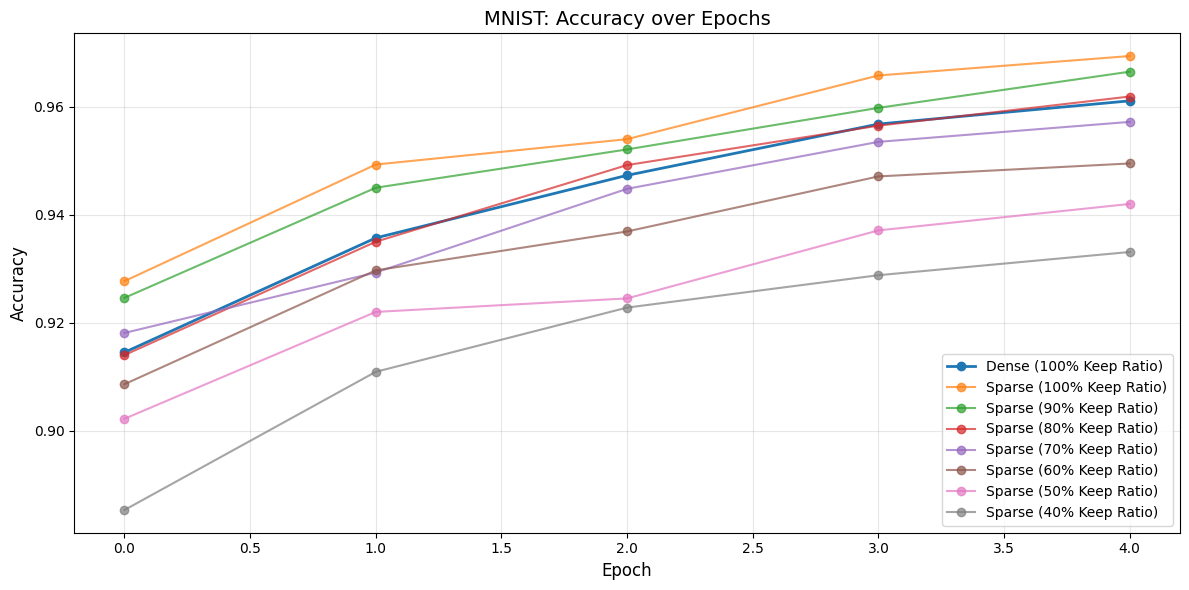

In [ ]:
# acc graph for full_dataset_name variable
for dataset_name, results in dataset_acc_results.items():
    dense_acc_result = dataset_acc_results[dataset_name]['dense']
    sparse_acc_result_map = dataset_acc_results[dataset_name]['sparse']
    sparse_keep_ratios = list(sparse_acc_result_map.keys())
    sparse_acc_results = list(sparse_acc_result_map.values())
    plot_accuracy_over_epochs(dense_acc_result, sparse_keep_ratios, sparse_acc_results, title=f'{dataset_name}: Accuracy over Epochs')



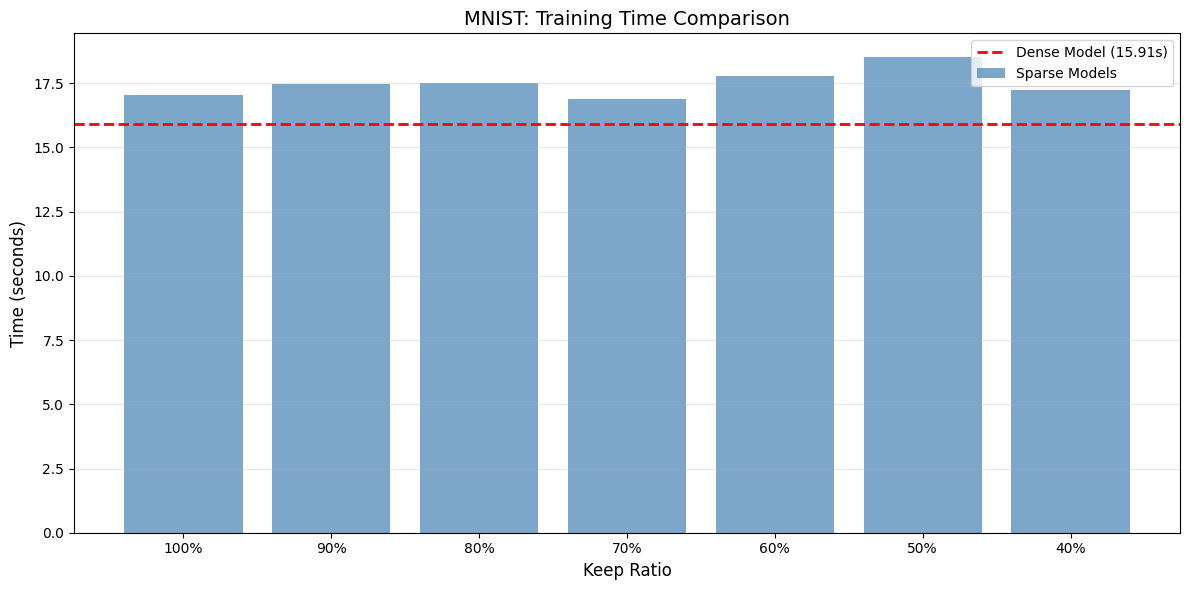

In [26]:
# time graph for full_dataset_name variable
for dataset_name, result_bundle in dataset_time_results.items():
        dense_time_result = result_bundle['dense']
        sparse_time_result_map = result_bundle['sparse']
        sparse_keep_ratios = list(sparse_time_result_map.keys())
        sparse_time_results = list(sparse_time_result_map.values())
        plot_training_time_comparison(sparse_keep_ratios, sparse_time_results, dense_time_result, title=f'{dataset_name}: Training Time Comparison')
